In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [ ]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
## X = feature matrix, Y = target array

In [7]:
X

array([[ 8.31871733e-02,  1.91116266e+00, -2.66429165e-01,
        -4.00737421e+00, -1.23713350e+00],
       [ 1.73870827e+00, -2.70237274e+00, -1.93442805e+00,
         1.21276247e+00, -7.70179848e-01],
       [-1.23827179e+00, -2.40850737e-01,  1.02385951e+00,
         4.96881817e-01, -7.03326132e-01],
       [-5.97766882e-01, -8.22902019e-02,  3.34919573e-01,
        -3.91213972e+00, -2.90539616e-01],
       [-2.74850778e+00,  5.68636543e-01,  3.01990849e+00,
        -3.96586063e+00, -4.51443920e-01],
       [-1.26876954e+00, -1.87982035e+00,  1.30276606e+00,
        -3.12942228e+00, -2.04033013e+00],
       [-1.56043351e+00, -6.50506408e-01,  1.62141859e+00,
        -2.86682951e+00, -4.38635479e-01],
       [-1.42861942e+00, -1.81993437e+00,  9.62531609e-01,
        -3.61260404e+00, -9.75774783e-01],
       [-2.00551311e-01,  3.48565984e-01, -2.06188235e-02,
        -3.09587388e+00, -4.72350202e-01],
       [-3.95262064e-02, -5.99316335e-01,  1.75137802e+00,
        -1.90396984e+00

In [18]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.083187,1.911163,-0.266429,-4.007374,-1.237133,1
1,1.738708,-2.702373,-1.934428,1.212762,-0.770180,1
2,-1.238272,-0.240851,1.023860,0.496882,-0.703326,0
3,-0.597767,-0.082290,0.334920,-3.912140,-0.290540,1
4,-2.748508,0.568637,3.019908,-3.965861,-0.451444,1


In [20]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [22]:
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [24]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [29]:
df1 = combined_sampling(df,0.5,0.5)
df1

,col1,col3,target
78,0.619616,-0.326165,1
62,-1.440191,0.882336,0
33,1.538243,-0.528159,1
60,-1.106203,0.977588,0
28,1.225683,-1.312436,1
71,0.992281,0.223335,1
37,-0.642798,1.160144,0
18,-1.160298,1.683551,1
31,-0.692525,-0.497695,1
61,-1.347851,2.019429,0


In [30]:
df2 = combined_sampling(df,0.5,0.5)
df2

,col3,col2,target
64,0.182490,0.367453,1
28,-1.312436,-1.321498,1
67,-0.023343,0.082675,0
25,-1.288899,-1.773527,1
65,1.496657,-2.965937,0
24,0.753206,-1.199303,0
85,0.043145,-2.651670,1
58,-1.294447,-0.822435,1
23,0.180744,-1.943752,1
0,-0.266429,1.911163,1


In [33]:
df3 = combined_sampling(df,0.5,0.5)
df3

,col5,col4,target
31,0.089869,-1.604523,1
27,-0.721373,-4.292132,1
71,-1.999314,1.317231,1
33,-1.938693,-1.909811,1
26,1.580659,-1.793111,0
31,0.089869,-1.604523,1
18,-1.003309,-1.973578,1
54,-0.636205,-0.571253,0
25,-0.780475,0.152991,1
34,-1.070707,0.254118,0


In [35]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col3', 'target'], dtype='str')
Index(['col3', 'col2', 'target'], dtype='str')
Index(['col5', 'col4', 'target'], dtype='str')


In [37]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
     

In [39]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [41]:
from sklearn.tree import plot_tree


[Text(0.5, 0.9166666666666666, 'x[1] <= 0.464\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.3, 0.75, 'x[0] <= -1.014\ngini = 0.071\nsamples = 27\nvalue = [1, 26]'),
 Text(0.4, 0.8333333333333333, 'True  '),
 Text(0.2, 0.5833333333333334, 'x[0] <= -1.526\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.5833333333333334, 'gini = 0.0\nsamples = 24\nvalue = [0, 24]'),
 Text(0.7, 0.75, 'x[0] <= -3.052\ngini = 0.227\nsamples = 23\nvalue = [20, 3]'),
 Text(0.6, 0.8333333333333333, '  False'),
 Text(0.6, 0.5833333333333334, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5833333333333334, 'x[0] <= 0.905\ngini = 0.165\nsamples = 22\nvalue = [20, 2]'),
 Text(0.7, 0.4166666666666667, 'x[1] <= 1.573\ngini = 0.091\nsamples = 21\nvalue = [20, 1]'),
 Text(0.6, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.

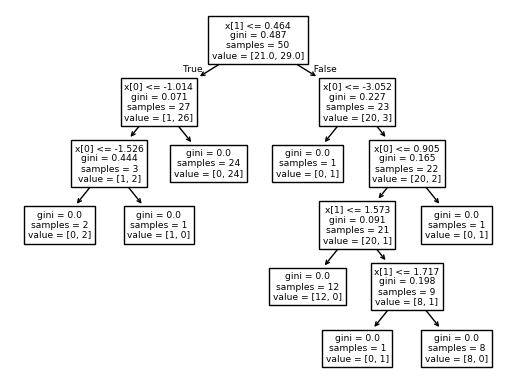

In [43]:
plot_tree(clf1)

[Text(0.4583333333333333, 0.9166666666666666, 'x[0] <= 0.27\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.16666666666666666, 0.75, 'x[1] <= -0.813\ngini = 0.278\nsamples = 30\nvalue = [5, 25]'),
 Text(0.3125, 0.8333333333333333, 'True  '),
 Text(0.08333333333333333, 0.5833333333333334, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.25, 0.5833333333333334, 'x[1] <= 0.101\ngini = 0.486\nsamples = 12\nvalue = [5, 7]'),
 Text(0.16666666666666666, 0.4166666666666667, 'x[0] <= -0.842\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.08333333333333333, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.75, 0.75, 'x[0] <= 1.682\ngini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.6041666666666666, 0.8333333333333333, '  False'),
 Text(0.6666666666666666, 0.5833333333333334, 'x[1] <= -2.432\ngini = 0.208\nsamples =

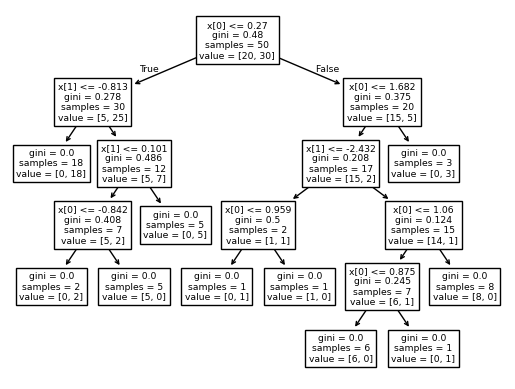

In [45]:
plot_tree(clf2)

[Text(0.3088235294117647, 0.9444444444444444, 'x[1] <= -4.218\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.25, 0.8333333333333334, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.27941176470588236, 0.8888888888888888, 'True  '),
 Text(0.36764705882352944, 0.8333333333333334, 'x[1] <= -2.033\ngini = 0.488\nsamples = 45\nvalue = [26.0, 19.0]'),
 Text(0.3382352941176471, 0.8888888888888888, '  False'),
 Text(0.11764705882352941, 0.7222222222222222, 'x[1] <= -3.291\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.058823529411764705, 0.6111111111111112, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.17647058823529413, 0.6111111111111112, 'x[1] <= -2.962\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.11764705882352941, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.23529411764705882, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6176470588235294, 0.7222222222222222, 'x[1] <= -0.869\ngini = 0.498\nsamples = 34\nvalue = [16, 18]'),
 Text(

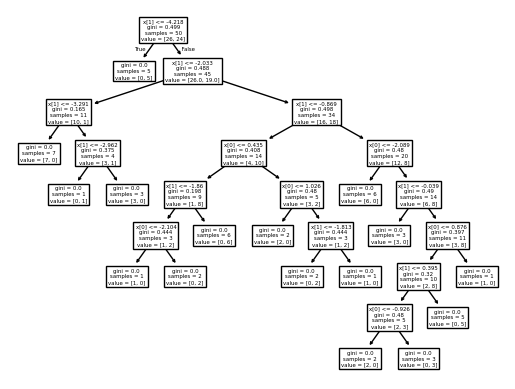

In [47]:
plot_tree(clf3)

In [49]:
clf1.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

c:\Users\anujj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [51]:
clf2.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

c:\Users\anujj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [53]:
clf3.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

c:\Users\anujj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
## Random forest uses majority vote and chooses 1